# Static and dynamic effective dimensionality, sparseness, and activity

This notebook computes three independent representation time courses for matched static-image and dynamic-movie responses:

1. covariance-eigenvalue participation ratio (effective dimensionality);
2. neuronal population sparseness; and
3. image/lifetime sparseness.

Each measure gets its own static-dynamic overlay. The notebook also shows exact min-max-normalized mean activity with across-neuron standard deviation, per-neuron last-frame/static and dynamic tuning curves, and an overlay of their population means. Static time is shifted to the selected source frame's movie onset: 2000, 2250, or 2500 ms.

In [1]:
import os
import sys
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import yaml
from scipy.ndimage import gaussian_filter1d


# Locate the repository from either the project root or scripts directory.
working_directory = Path.cwd().resolve()
project_candidates = (working_directory, *working_directory.parents)
PROJECT_ROOT = next(
    candidate for candidate in project_candidates
    if (candidate / 'config.yaml').is_file()
)
ENV = os.getenv('MY_ENV', 'tiziano_mac_mini')

with open(PROJECT_ROOT / 'config.yaml', 'r') as file:
    config = yaml.safe_load(file)
# end with open

paths = config[ENV]['paths']
for source_path in (paths['src_path'], paths['useful_stuff_path']):
    if source_path not in sys.path:
        sys.path.append(source_path)
    # end if source_path
# end for source_path

from project_specific_utils import (
    load_binned_raster, load_natraster, load_raster_presentation_names,
    match_timed_static_movie_rasters, representation_measure_timecourses,
    split_half_cvpca_timecourses, stimulus_min_max_normalization,
    window_mean_responses,
)
from useful_stuff.general_utils import TimeSeries


## Definitions and centering

For non-negative values $x_j$, the shared effective participation-ratio function is

$$\mathrm{PR}(x)=\frac{(\sum_j x_j)^2}{\sum_j x_j^2}. $$

Dividing by the number of entries gives $a=(\mathrm{mean}\ x)^2/\mathrm{mean}(x^2)$. The DNNDYnamics/Treves-Rolls measure is $S=1-a$. Changing only the reduction axis gives population sparseness over neurons and lifetime sparseness over images. High population sparseness means few neurons dominate, while high lifetime sparseness means neurons are selective for few images. The complementary activity participation-ratio curves are intentionally not shown.

Centering is intentionally measure-specific:

- **Eigenvalue PR:** each neuron is centered across matched images independently at every timepoint before computing covariance eigenvalues.
- **Sparseness:** responses are not mean-centered, because signed responses invalidate the sparseness interpretation. Instead, each neuron/timepoint is robustly scaled across images between the configured percentiles and clipped to $[0,1]$, matching the normalization described in DNNDYnamics.pdf.

The `natraster` inputs are already averaged over presentations. Consequently these curves use all matched images and do not reproduce the paper's raw-trial even/odd cross-validated top-image selection.

In [2]:
@dataclass
class Cfg:
    static_exp_name: str = 'baby1_260718to27' # "red_20260726to27" # 
    dynamic_exp_name: str = 'baby1_260716to24' #"red_20260720to24" # 
    static_responses: tuple[str, ...] = (
        '2000ms', '2250ms', 'last_frame',
    )
    # One-based MATLAB channel numbers with both endpoints included.
    good_channels: tuple[int, int] | None =  (84, 186) #(101, 109) # None #
    # Intersect good_channels with the static-session reliability list.
    use_reliable_channels: bool = True
    reliable_channels_config: Path | None = None
    reliable_channels_key: str | None = None
    source_fs: float = 1000
    analysis_fs: float = 100
    # Gaussian temporal smoothing SD in ms; None or 0 keeps raw curves.
    smoothing_sigma_ms: float | None = 10
    run_split_half_cvpca: bool = False
    n_split_repeats: int = 2
    random_seed: int = 0
    percentile_bounds: tuple[float, float] = (2.5, 97.5)
    # Tuning windows are relative to each condition's onset.
    tuning_static_window_ms: tuple[float, float] = (60, 200)
    # None aligns the dynamic window to the 2500 ms last-frame onset.
    tuning_dynamic_window_ms: tuple[float, float] | None = None
    tuning_neuron_alpha: float = 0.08
    figure_size: tuple[float, float] = (10, 5)
    figure_dpi: int = 120
    xlim_ms: tuple[float, float] | None = (0, 3500)
    save_outputs: bool = False
# EOC


cfg = Cfg()
frame_onset_ms = {
    '2000ms': 2000.0,
    '2250ms': 2250.0,
    'last_frame': 2500.0,
}
invalid_responses = set(cfg.static_responses) - set(frame_onset_ms)
if invalid_responses:
    raise ValueError(
        f'Unsupported static responses: {sorted(invalid_responses)}'
    )
# end if invalid_responses
if len(cfg.static_responses) != len(set(cfg.static_responses)):
    raise ValueError('static_responses must not contain duplicates.')
# end if duplicate static responses
if cfg.source_fs <= 0 or cfg.analysis_fs <= 0:
    raise ValueError('source_fs and analysis_fs must be positive.')
# end if invalid sampling frequency
if cfg.smoothing_sigma_ms is not None and cfg.smoothing_sigma_ms < 0:
    raise ValueError('smoothing_sigma_ms must be non-negative or None.')
# end if invalid smoothing width
if cfg.n_split_repeats < 1:
    raise ValueError('n_split_repeats must be positive.')
# end if invalid split count
if 'last_frame' not in cfg.static_responses:
    raise ValueError(
        "static_responses must include 'last_frame' for tuning plots."
    )
# end if last_frame is unavailable for tuning
if not 0 < cfg.tuning_neuron_alpha <= 1:
    raise ValueError('tuning_neuron_alpha must be in (0, 1].')
# end if invalid tuning alpha

plt.rcParams['figure.dpi'] = cfg.figure_dpi
cfg


Cfg(static_exp_name='baby1_260718to27', dynamic_exp_name='baby1_260716to24', static_responses=('2000ms', '2250ms', 'last_frame'), good_channels=(84, 186), use_reliable_channels=True, reliable_channels_config=None, reliable_channels_key=None, source_fs=1000, analysis_fs=100, smoothing_sigma_ms=10, run_split_half_cvpca=False, n_split_repeats=2, random_seed=0, percentile_bounds=(2.5, 97.5), tuning_static_window_ms=(60, 200), tuning_dynamic_window_ms=None, tuning_neuron_alpha=0.08, figure_size=(10, 5), figure_dpi=120, xlim_ms=(0, 3500), save_outputs=False)

## Load, select channels, and align stimuli

The three static frame conditions and the movie condition are matched by the identity following `img_`, `img_2000ms_`, `img_2250ms_`, or `vid_`. Channel selection occurs before alignment to avoid retaining unnecessary large arrays. `good_channels` defines an optional inclusive one-based range. When `use_reliable_channels=True`, that range is intersected with the channel list in `reliable_channels.yaml`; `reliable_channels_key` defaults to the static experiment so the same physical channels are used for both sessions.

In [3]:
data_dir = Path(paths['data_path']) / 'data'
static_path = data_dir / f'{cfg.static_exp_name}_natraster_img.mat'
dynamic_path = data_dir / f'{cfg.dynamic_exp_name}_natraster_vid.mat'

# By default, use the reliability list estimated from the static session.
reliable_channels_config = None
reliable_channels_key = None
if cfg.use_reliable_channels:
    reliable_channels_config = (
        cfg.reliable_channels_config
        or PROJECT_ROOT / 'reliable_channels.yaml'
    )
    reliable_channels_key = (
        cfg.reliable_channels_key or cfg.static_exp_name
    )
# end if cfg.use_reliable_channels

# Apply the identical physical-channel selection to both sessions.
loaded_static, static_names, static_channel_numbers = load_natraster(
    static_path,
    good_channels=cfg.good_channels,
    reliable_channels_config=reliable_channels_config,
    reliable_channels_key=reliable_channels_key,
    return_channel_numbers=True,
)
loaded_dynamic, dynamic_names, dynamic_channel_numbers = load_natraster(
    dynamic_path,
    good_channels=cfg.good_channels,
    reliable_channels_config=reliable_channels_config,
    reliable_channels_key=reliable_channels_key,
    return_channel_numbers=True,
)
if not np.array_equal(static_channel_numbers, dynamic_channel_numbers):
    raise ValueError(
        'Static and dynamic sessions retained different physical channels.'
    )
# end if retained channels differ
channel_numbers = static_channel_numbers

(
    last_frame_rasters, dynamic_rasters,
    image_2000ms_rasters, image_2250ms_rasters,
    shared_stimuli, aligned_names,
) = match_timed_static_movie_rasters(
    loaded_static, static_names, loaded_dynamic, dynamic_names,
)
del loaded_static, loaded_dynamic

static_rasters_by_response = {
    '2000ms': image_2000ms_rasters,
    '2250ms': image_2250ms_rasters,
    'last_frame': last_frame_rasters,
}
print(f'Static natraster:  {static_path}')
print(f'Dynamic natraster: {dynamic_path}')
print(f'Reliable-channel filter: {cfg.use_reliable_channels}')
if cfg.use_reliable_channels:
    print(f'Reliability config: {reliable_channels_config}')
    print(f'Reliability key: {reliable_channels_key}')
# end if cfg.use_reliable_channels
print(f'Matched stimuli: {len(shared_stimuli)}')
print(f'Selected MATLAB channels: {channel_numbers.tolist()}')
print(f'Selected channel count: {len(channel_numbers)}')
print('Dynamic shape:', dynamic_rasters.shape)
for response in cfg.static_responses:
    print(f'{response:>10} shape:', static_rasters_by_response[response].shape)
# end for response


Static natraster:  /Users/tizianocausin/sd_local/data/baby1_260718to27_natraster_img.mat
Dynamic natraster: /Users/tizianocausin/sd_local/data/baby1_260716to24_natraster_vid.mat
Reliable-channel filter: True
Reliability config: /Users/tizianocausin/Desktop/static_dynamic/reliable_channels.yaml
Reliability key: baby1_260718to27
Matched stimuli: 100
Selected MATLAB channels: [101, 102, 103, 104, 105, 106, 107, 108, 109, 121, 122, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 158, 159, 160, 161, 162, 163, 164, 165]
Selected channel count: 30
Dynamic shape: (30, 3500, 100)
    2000ms shape: (30, 1000, 100)
    2250ms shape: (30, 1000, 100)
last_frame shape: (30, 1000, 100)


## Resample and compute every timepoint independently

No temporal window averaging is applied when computing the measures. Each raw output sample is computed only from its own neurons-by-images response matrix. `analysis_fs` controls the time resolution; set it equal to `source_fs` for the original 1 ms samples. Optional Gaussian smoothing is applied only to the finished one-dimensional measure curves, never to the neural responses or covariance matrices.

In [4]:
dynamic_series = TimeSeries(dynamic_rasters, cfg.source_fs)
if cfg.analysis_fs != cfg.source_fs:
    dynamic_series.resample(cfg.analysis_fs)
# end if resampling dynamic responses
dynamic_responses = dynamic_series.get_array()
dynamic_times_ms = (
    np.arange(dynamic_responses.shape[1]) * 1000 / cfg.analysis_fs
)
dynamic_measures = representation_measure_timecourses(
    dynamic_responses, percentile_bounds=cfg.percentile_bounds,
)
normalized_dynamic_activity = stimulus_min_max_normalization(
    dynamic_responses,
)
dynamic_activity_by_neuron = normalized_dynamic_activity.mean(axis=2)
dynamic_activity_mean = dynamic_activity_by_neuron.mean(axis=0)
dynamic_activity_std = dynamic_activity_by_neuron.std(axis=0)
del normalized_dynamic_activity

static_times_ms_by_response = {}
static_measures_by_response = {}
static_responses_by_response = {}
static_activity_mean_by_response = {}
static_activity_std_by_response = {}
for response in cfg.static_responses:
    static_series = TimeSeries(
        static_rasters_by_response[response], cfg.source_fs,
    )
    if cfg.analysis_fs != cfg.source_fs:
        static_series.resample(cfg.analysis_fs)
    # end if resampling static responses
    static_responses = static_series.get_array()
    static_responses_by_response[response] = static_responses
    local_static_times_ms = (
        np.arange(static_responses.shape[1]) * 1000 / cfg.analysis_fs
    )
    # Shift time zero to the corresponding source frame in the movie.
    static_times_ms_by_response[response] = (
        local_static_times_ms + frame_onset_ms[response]
    )
    static_measures_by_response[response] = (
        representation_measure_timecourses(
            static_responses,
            percentile_bounds=cfg.percentile_bounds,
        )
    )
    normalized_static_activity = stimulus_min_max_normalization(
        static_responses,
    )
    static_activity_by_neuron = normalized_static_activity.mean(axis=2)
    static_activity_mean_by_response[response] = (
        static_activity_by_neuron.mean(axis=0)
    )
    static_activity_std_by_response[response] = (
        static_activity_by_neuron.std(axis=0)
    )
    del normalized_static_activity, static_activity_by_neuron
# end for response

# Compare last-frame static and dynamic tuning in matched response windows.
if cfg.tuning_dynamic_window_ms is None:
    tuning_dynamic_window_ms = tuple(
        frame_onset_ms['last_frame'] + local_time_ms
        for local_time_ms in cfg.tuning_static_window_ms
    )
else:
    tuning_dynamic_window_ms = cfg.tuning_dynamic_window_ms
# end if automatic dynamic tuning alignment
static_tuning_responses, static_tuning_sample_window = (
    window_mean_responses(
        static_responses_by_response['last_frame'],
        cfg.tuning_static_window_ms, cfg.analysis_fs,
    )
)
dynamic_tuning_responses, dynamic_tuning_sample_window = (
    window_mean_responses(
        dynamic_responses, tuning_dynamic_window_ms, cfg.analysis_fs,
    )
)
normalized_static_tuning = stimulus_min_max_normalization(
    static_tuning_responses,
)
normalized_dynamic_tuning = stimulus_min_max_normalization(
    dynamic_tuning_responses,
)
# Rank stimuli independently for every neuron and condition. Stimulus
# identities are intentionally discarded in these tuning-profile plots.
ranked_static_tuning = np.sort(
    normalized_static_tuning, axis=1,
)[:, ::-1]
ranked_dynamic_tuning = np.sort(
    normalized_dynamic_tuning, axis=1,
)[:, ::-1]
static_tuning_mean = ranked_static_tuning.mean(axis=0)
dynamic_tuning_mean = ranked_dynamic_tuning.mean(axis=0)

# Keep the independently computed raw measures and smooth only the curves
# used for plotting and optional plotted-array export.
smoothing_sigma_samples = 0.0
if cfg.smoothing_sigma_ms is not None:
    smoothing_sigma_samples = (
        cfg.smoothing_sigma_ms * cfg.analysis_fs / 1000
    )
# end if cfg.smoothing_sigma_ms is not None
if smoothing_sigma_samples > 0:
    plotting_dynamic_measures = {
        measure_name: gaussian_filter1d(
            values, sigma=smoothing_sigma_samples, mode='nearest',
        )
        for measure_name, values in dynamic_measures.items()
    }
    plotting_static_measures_by_response = {
        response: {
            measure_name: gaussian_filter1d(
                values, sigma=smoothing_sigma_samples, mode='nearest',
            )
            for measure_name, values in measures.items()
        }
        for response, measures in static_measures_by_response.items()
    }
    smoothing_label = (
        f'Gaussian smoothing: sigma={cfg.smoothing_sigma_ms:g} ms'
    )
else:
    plotting_dynamic_measures = dynamic_measures
    plotting_static_measures_by_response = static_measures_by_response
    smoothing_label = 'unsmoothed'
# end if smoothing_sigma_samples > 0

print(
    f'Computed {len(dynamic_times_ms)} dynamic timepoints and '
    f'{len(local_static_times_ms)} timepoints per static response.'
)
print(smoothing_label)


Computed 350 dynamic timepoints and 100 timepoints per static response.
Gaussian smoothing: sigma=10 ms


## Numerical checks

Both sparseness measures must remain in $[0,1]$. Eigenvalue PR must lie between one and the smaller of the neuron and image counts whenever covariance is non-zero.

In [5]:
all_condition_measures = {
    'dynamic': dynamic_measures,
    **static_measures_by_response,
}
maximum_dimension = min(len(channel_numbers), len(shared_stimuli))
for condition, measures in all_condition_measures.items():
    for sparseness_name in (
            'population_sparseness', 'lifetime_sparseness',
            ):
        sparseness = measures[sparseness_name]
        if np.nanmin(sparseness) < -1e-10:
            raise AssertionError(
                f'{condition} {sparseness_name} is below zero.'
            )
        # end if sparseness is below zero
        if np.nanmax(sparseness) > 1 + 1e-10:
            raise AssertionError(
                f'{condition} {sparseness_name} exceeds one.'
            )
        # end if sparseness exceeds one
    # end for sparseness_name
    finite_dimension = measures['dimensionality_pr'][
        np.isfinite(measures['dimensionality_pr'])
    ]
    if finite_dimension.size:
        if finite_dimension.min() < 1 - 1e-10:
            raise AssertionError(f'{condition} dimensionality PR is below 1.')
        # end if dimensionality is below one
        if finite_dimension.max() > maximum_dimension + 1e-10:
            raise AssertionError(
                f'{condition} dimensionality PR exceeds {maximum_dimension}.'
            )
        # end if dimensionality exceeds its rank bound
    # end if finite dimensionality values
    print(
        f'{condition:>10}: dimensionality PR '
        f'{np.nanmin(finite_dimension):.3f}-'
        f'{np.nanmax(finite_dimension):.3f}'
    )
# end for condition


   dynamic: dimensionality PR 2.849-21.290
    2000ms: dimensionality PR 1.837-17.931
    2250ms: dimensionality PR 1.737-18.096
last_frame: dimensionality PR 1.628-19.930


## Split-half cvPCA dimensionality

This section uses the raw presentation-level raster files. Repetitions are divided independently within every stimulus, each half is averaged, and neurons are centered across images separately in the two halves. PCA directions are fitted only on the first half; signal variance along those directions is the covariance between first- and second-half projections. Trial noise that is independent between halves has zero expected covariance.

Finite data can produce negative cross-validated variances. They are retained in the diagnostic below, but only positive cvPCA variances enter PR because negative variance cannot define a covariance dimension. A large negative-spectrum fraction indicates that the corresponding PR estimate is noise-limited. Raw rasters are averaged into non-overlapping temporal bins while loading, avoiding multi-gigabyte full-resolution arrays.

In [6]:
split_half_results_by_condition = {}
if cfg.run_split_half_cvpca:
    split_rng = np.random.default_rng(cfg.random_seed)
    raw_static_path = data_dir / f'{cfg.static_exp_name}_raster_img.mat'
    raw_dynamic_path = data_dir / f'{cfg.dynamic_exp_name}_raster_vid.mat'
    raw_static_names = load_raster_presentation_names(raw_static_path)
    raw_dynamic_names = load_raster_presentation_names(raw_dynamic_path)
    shared_stimulus_set = set(shared_stimuli)
    first_loaded_channel = int(channel_numbers[0])
    last_loaded_channel = int(channel_numbers[-1])
    contiguous_channel_slice = slice(
        first_loaded_channel - 1, last_loaded_channel,
    )
    selected_channel_offsets = channel_numbers - first_loaded_channel

    # Select only matched movie presentations before loading neural data.
    dynamic_candidate_identities = []
    for presentation_name in raw_dynamic_names:
        stem = Path(presentation_name).stem
        identity = stem[len('vid_'):] if stem.startswith('vid_') else None
        dynamic_candidate_identities.append(identity)
    # end for presentation_name
    dynamic_presentation_indices = np.asarray([
        index for index, identity in enumerate(dynamic_candidate_identities)
        if identity in shared_stimulus_set
    ], dtype=int)
    dynamic_presentation_identities = [
        dynamic_candidate_identities[index]
        for index in dynamic_presentation_indices
    ]
    print('Loading temporally binned dynamic presentations...')
    dynamic_split_rasters, _ = load_binned_raster(
        raw_dynamic_path, cfg.source_fs, cfg.analysis_fs,
        channel_slice=contiguous_channel_slice,
        presentation_indices=dynamic_presentation_indices,
    )
    # Retain a potentially non-contiguous reliability selection.
    dynamic_split_rasters = dynamic_split_rasters[
        selected_channel_offsets
    ]
    split_half_results_by_condition['dynamic'] = (
        split_half_cvpca_timecourses(
            dynamic_split_rasters, dynamic_presentation_identities,
            shared_stimuli, cfg.n_split_repeats, split_rng,
        )
    )
    del dynamic_split_rasters

    static_prefixes = {
        '2000ms': 'img_2000ms_',
        '2250ms': 'img_2250ms_',
        'last_frame': 'img_',
    }
    for response in cfg.static_responses:
        static_candidate_identities = []
        for presentation_name in raw_static_names:
            stem = Path(presentation_name).stem
            if stem.startswith(static_prefixes['2000ms']):
                observed_response = '2000ms'
            elif stem.startswith(static_prefixes['2250ms']):
                observed_response = '2250ms'
            elif stem.startswith(static_prefixes['last_frame']):
                observed_response = 'last_frame'
            else:
                observed_response = None
            # end if static presentation prefix
            if observed_response == response:
                identity = stem[len(static_prefixes[response]):]
            else:
                identity = None
            # end if observed_response matches requested response
            static_candidate_identities.append(identity)
        # end for presentation_name
        static_presentation_indices = np.asarray([
            index for index, identity in enumerate(static_candidate_identities)
            if identity in shared_stimulus_set
        ], dtype=int)
        static_presentation_identities = [
            static_candidate_identities[index]
            for index in static_presentation_indices
        ]
        print(f'Loading temporally binned static {response} presentations...')
        static_split_rasters, _ = load_binned_raster(
            raw_static_path, cfg.source_fs, cfg.analysis_fs,
            channel_slice=contiguous_channel_slice,
            presentation_indices=static_presentation_indices,
        )
        # Retain the same physical channels as the natraster analysis.
        static_split_rasters = static_split_rasters[
            selected_channel_offsets
        ]
        split_half_results_by_condition[response] = (
            split_half_cvpca_timecourses(
                static_split_rasters, static_presentation_identities,
                shared_stimuli, cfg.n_split_repeats, split_rng,
            )
        )
        del static_split_rasters
    # end for response

    if (
            split_half_results_by_condition['dynamic']['cvpca_pr_mean'].size
            != dynamic_times_ms.size
            ):
        raise AssertionError('Dynamic split-half and natraster times differ.')
    # end if dynamic time axes differ
    for response in cfg.static_responses:
        if (
                split_half_results_by_condition[response]['cvpca_pr_mean'].size
                != static_times_ms_by_response[response].size
                ):
            raise AssertionError(
                f'{response} split-half and natraster times differ.'
            )
        # end if static time axes differ
    # end for response
    print(
        f'Completed {cfg.n_split_repeats} cvPCA splits per condition.'
    )
else:
    print('Split-half cvPCA disabled in cfg.')
# end if cfg.run_split_half_cvpca


Split-half cvPCA disabled in cfg.


In [7]:
if cfg.run_split_half_cvpca:
    static_colors = {
        '2000ms': 'tab:blue',
        '2250ms': 'tab:green',
        'last_frame': 'tab:red',
    }
    output_dir = (
        PROJECT_ROOT / 'results' / 'static_dynamic_participation_sparsity'
    )
    if cfg.save_outputs:
        output_dir.mkdir(parents=True, exist_ok=True)
    # end if cfg.save_outputs
    cvpca_plot_summaries = {}
    for condition, results in split_half_results_by_condition.items():
        pr_splits = results['cvpca_pr_splits']
        negative_splits = results['negative_spectrum_fraction_splits']
        if smoothing_sigma_samples > 0:
            pr_splits = gaussian_filter1d(
                pr_splits, sigma=smoothing_sigma_samples,
                axis=1, mode='nearest',
            )
            negative_splits = gaussian_filter1d(
                negative_splits, sigma=smoothing_sigma_samples,
                axis=1, mode='nearest',
            )
        # end if smoothing split curves
        cvpca_plot_summaries[condition] = {
            'pr_mean': np.nanmean(pr_splits, axis=0),
            'pr_lower': np.nanpercentile(pr_splits, 2.5, axis=0),
            'pr_upper': np.nanpercentile(pr_splits, 97.5, axis=0),
            'negative_mean': np.nanmean(negative_splits, axis=0),
            'negative_lower': np.nanpercentile(negative_splits, 2.5, axis=0),
            'negative_upper': np.nanpercentile(negative_splits, 97.5, axis=0),
        }
    # end for condition

    for diagnostic_name, title, ylabel in (
            (
                'pr', 'Split-half cvPCA participation ratio',
                'Positive cross-validated dimensionality',
            ),
            (
                'negative', 'cvPCA negative-spectrum diagnostic',
                'Negative absolute spectrum fraction',
            ),
            ):
        figure, axis = plt.subplots(
            figsize=cfg.figure_size, constrained_layout=True,
        )
        dynamic_summary = cvpca_plot_summaries['dynamic']
        axis.plot(
            dynamic_times_ms, dynamic_summary[f'{diagnostic_name}_mean'],
            color='black', linewidth=2.5, label='dynamic movie',
        )
        axis.fill_between(
            dynamic_times_ms, dynamic_summary[f'{diagnostic_name}_lower'],
            dynamic_summary[f'{diagnostic_name}_upper'],
            color='black', alpha=0.12,
        )
        for response in cfg.static_responses:
            color = static_colors[response]
            summary = cvpca_plot_summaries[response]
            times_ms = static_times_ms_by_response[response]
            axis.plot(
                times_ms, summary[f'{diagnostic_name}_mean'],
                color=color, linewidth=2, label=f'static {response}',
            )
            axis.fill_between(
                times_ms, summary[f'{diagnostic_name}_lower'],
                summary[f'{diagnostic_name}_upper'],
                color=color, alpha=0.12,
            )
            axis.axvline(
                frame_onset_ms[response], color=color, linestyle=':',
                linewidth=1, alpha=0.7,
            )
        # end for response
        axis.set(
            title=f'{title} ({smoothing_label})',
            xlabel='Movie-aligned time (ms)', ylabel=ylabel,
        )
        if cfg.xlim_ms is not None:
            axis.set_xlim(*cfg.xlim_ms)
        # end if cfg.xlim_ms
        if diagnostic_name == 'negative':
            axis.set_ylim(0, 1)
        # end if negative-spectrum diagnostic
        axis.grid(alpha=0.2)
        axis.legend(ncol=2)
        if cfg.save_outputs:
            figure.savefig(
                output_dir / f'cvpca_{diagnostic_name}.png',
                dpi=200, bbox_inches='tight',
            )
        # end if cfg.save_outputs
        plt.show()
    # end for diagnostic_name
# end if cfg.run_split_half_cvpca


## Static-dynamic measures, activity, and tuning

The dynamic movie is black. Each static trace begins exactly at its frame's movie time and extends through the static response. Vertical dotted lines mark those frame onsets. For activity, every neuron is independently min-max normalized across matched stimuli at each time bin; stimuli are then averaged within each neuron, and the plot shows the mean $\pm$ standard deviation across neurons.

Tuning is averaged over 60--200 ms after the last-frame static onset and, by default, the aligned 2560--2700 ms dynamic window. Each neuron is independently min-max normalized and independently sorted from its highest to lowest stimulus response within each condition. Stimulus identities are deliberately discarded: the x-axis is within-neuron preference rank, so these plots compare only the shapes of monotonically decreasing tuning profiles.

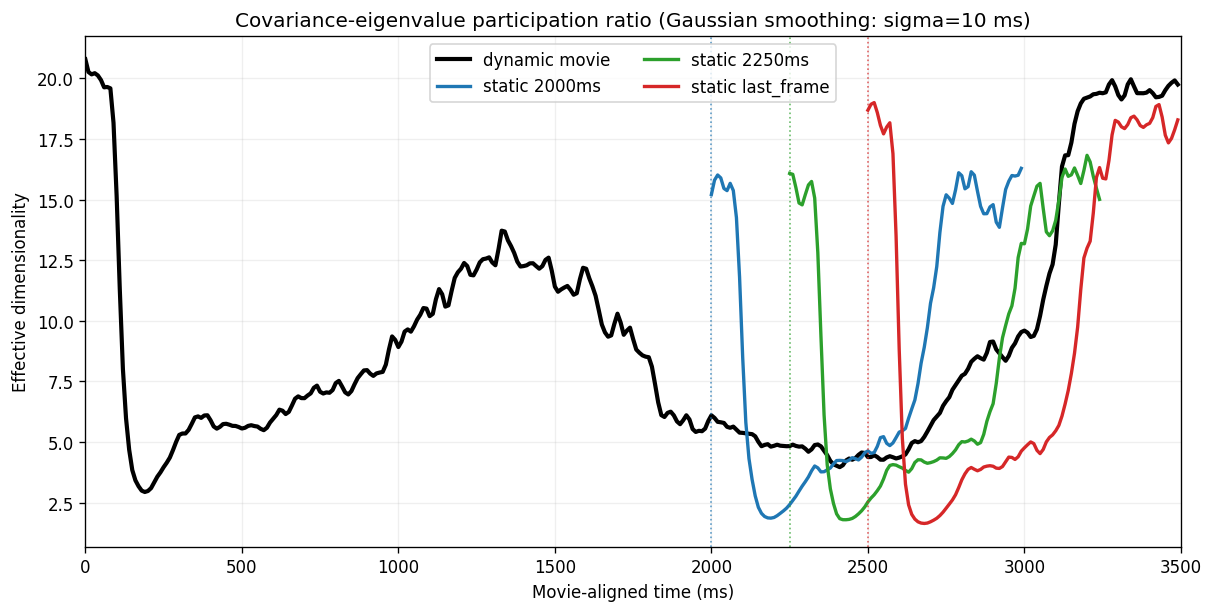

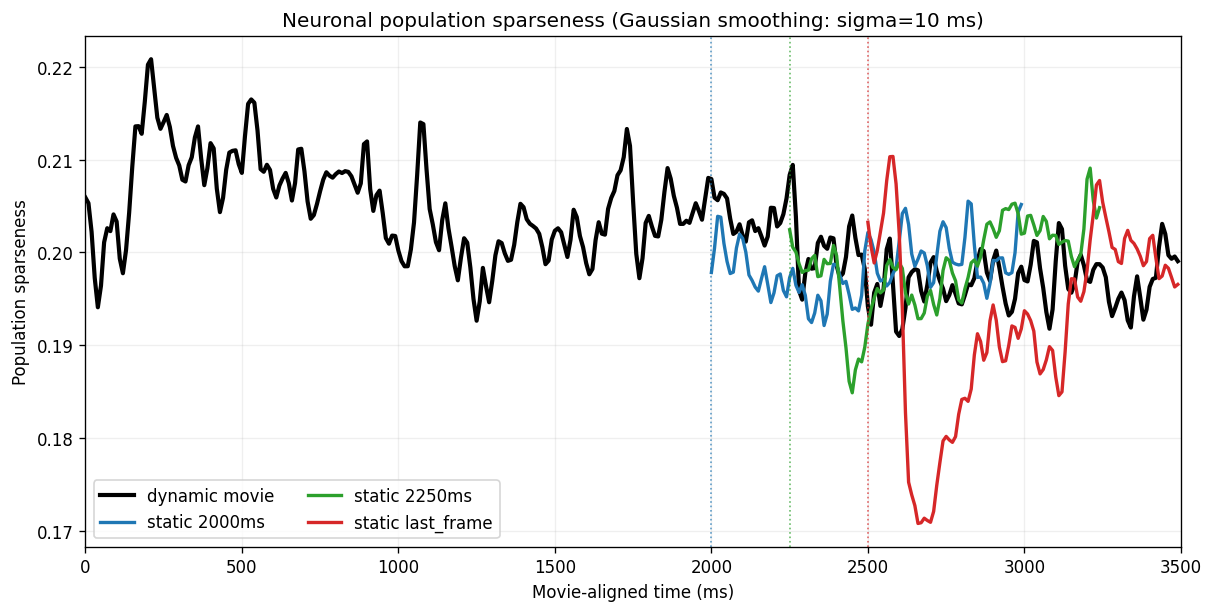

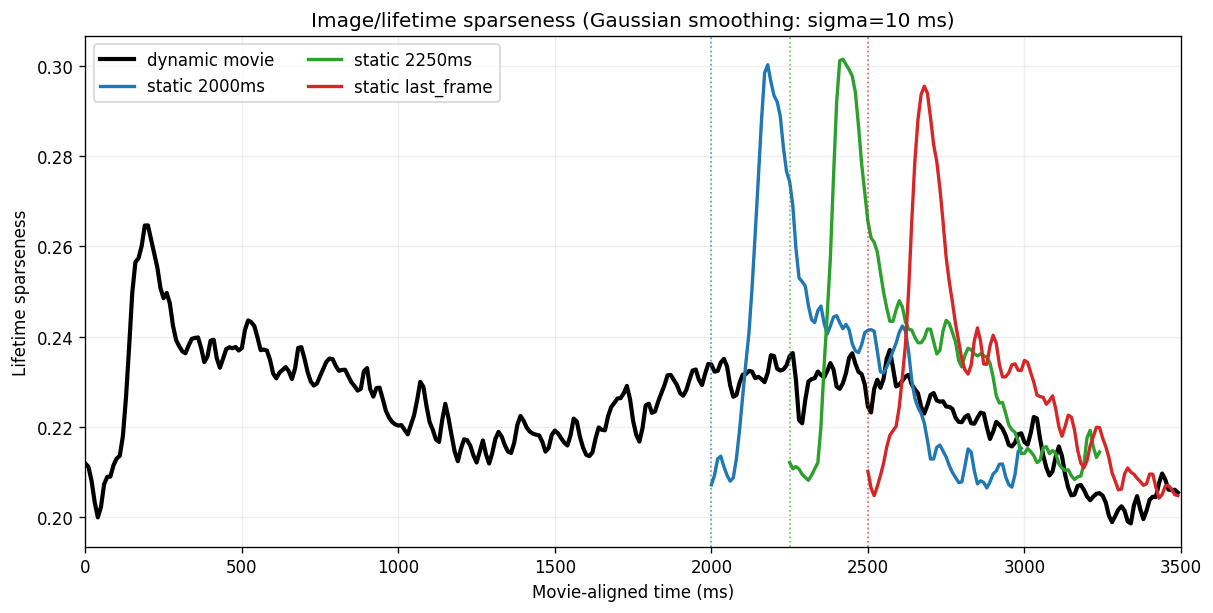

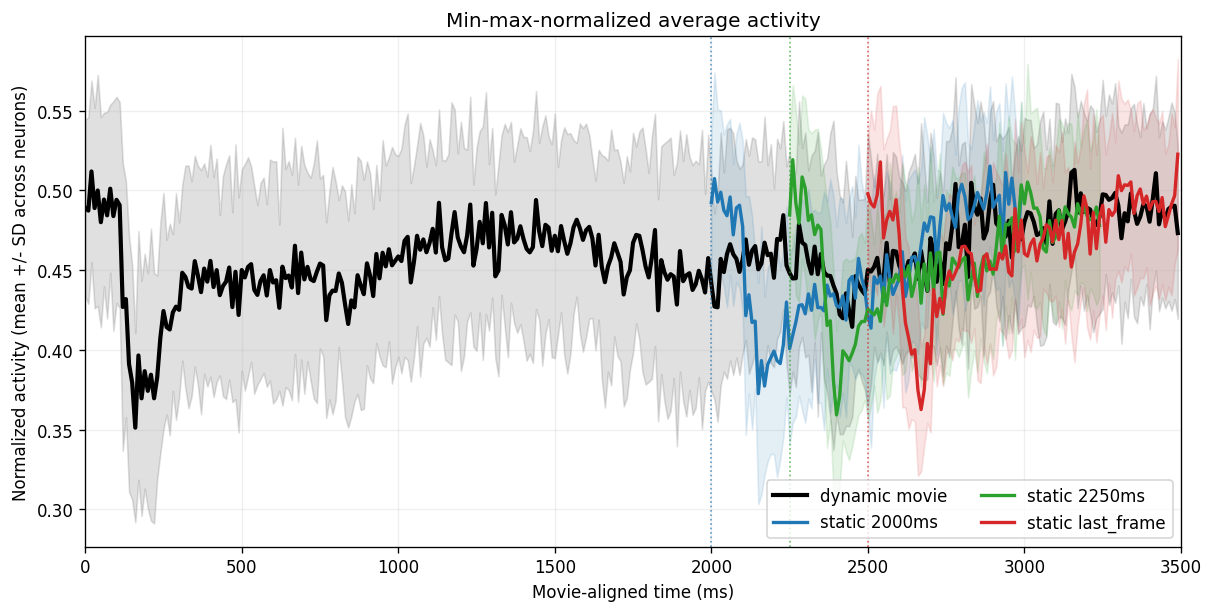

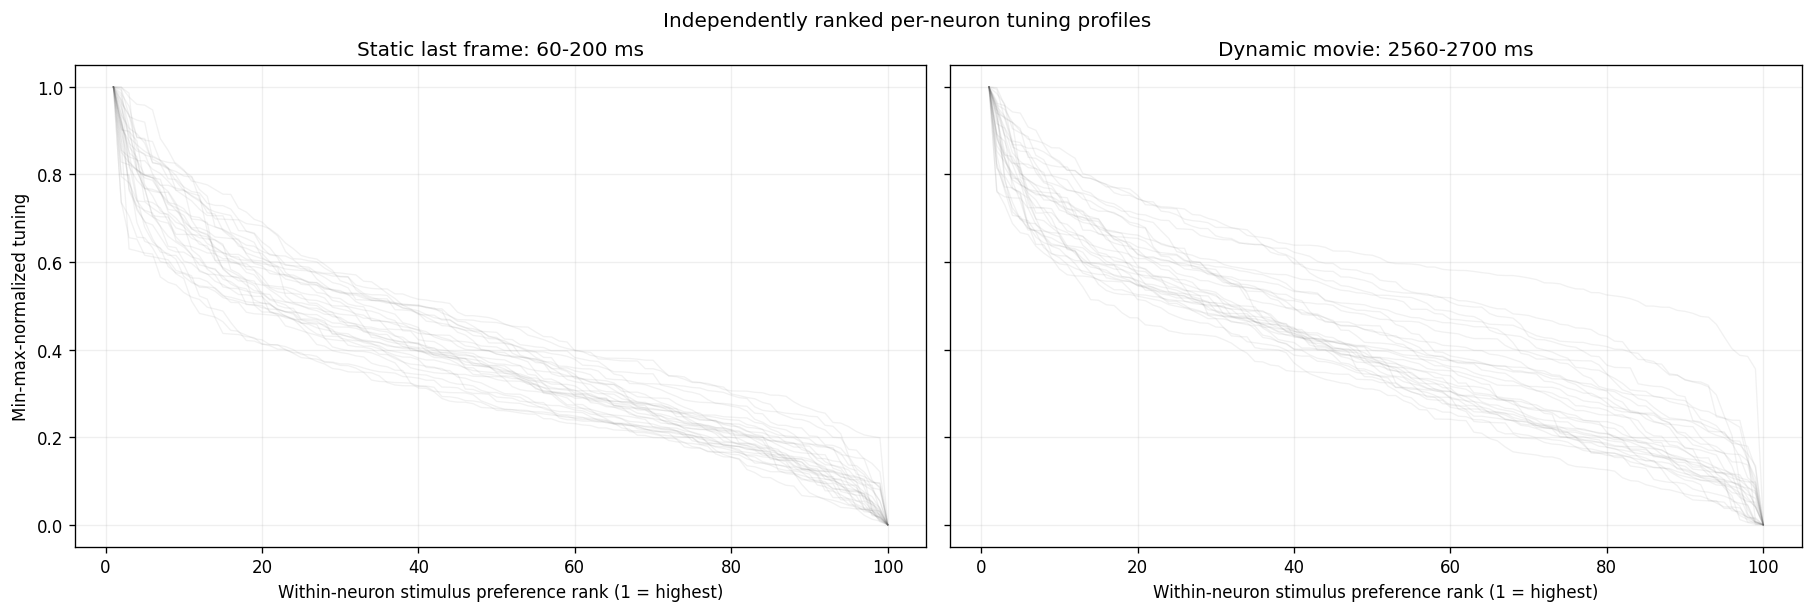

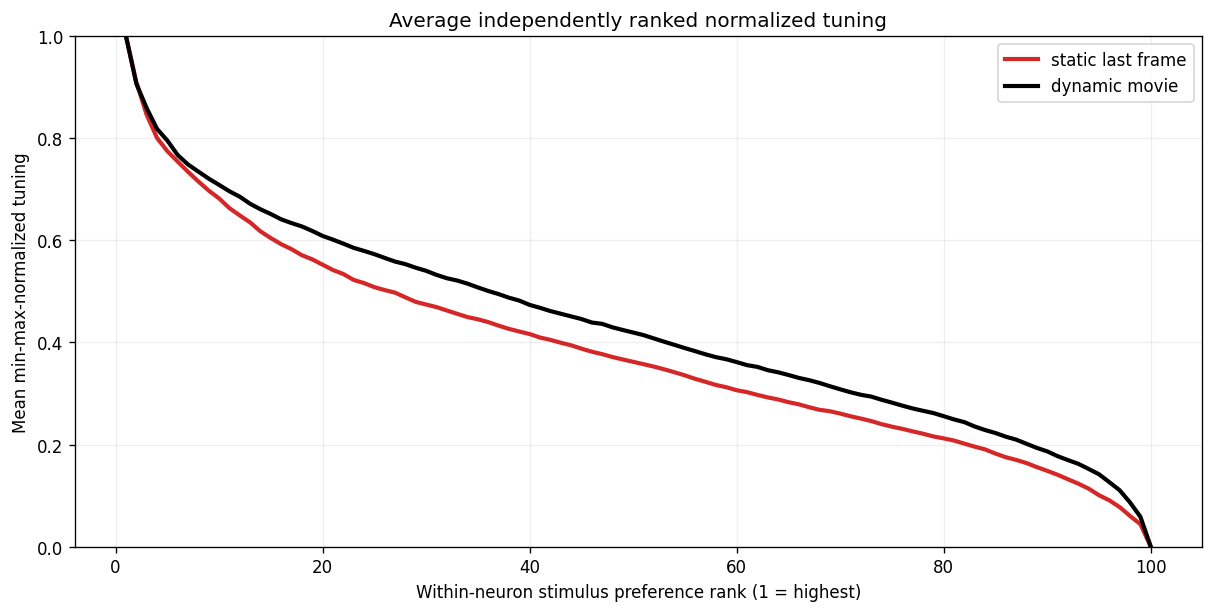

In [8]:
measure_specs = {
    'dimensionality_pr': (
        'Covariance-eigenvalue participation ratio',
        'Effective dimensionality',
    ),
    'population_sparseness': (
        'Neuronal population sparseness',
        'Population sparseness',
    ),
    'lifetime_sparseness': (
        'Image/lifetime sparseness',
        'Lifetime sparseness',
    ),
}
static_colors = {
    '2000ms': 'tab:blue',
    '2250ms': 'tab:green',
    'last_frame': 'tab:red',
}
output_dir = (
    PROJECT_ROOT / 'results' / 'static_dynamic_participation_sparsity'
)
if cfg.save_outputs:
    output_dir.mkdir(parents=True, exist_ok=True)
# end if cfg.save_outputs

for measure_name, (title, ylabel) in measure_specs.items():
    figure, axis = plt.subplots(
        figsize=cfg.figure_size, constrained_layout=True,
    )
    axis.plot(
        dynamic_times_ms, plotting_dynamic_measures[measure_name],
        color='black', linewidth=2.5, label='dynamic movie',
    )
    for response in cfg.static_responses:
        color = static_colors[response]
        axis.plot(
            static_times_ms_by_response[response],
            plotting_static_measures_by_response[response][measure_name],
            color=color, linewidth=2, label=f'static {response}',
        )
        axis.axvline(
            frame_onset_ms[response], color=color, linestyle=':',
            linewidth=1, alpha=0.7,
        )
    # end for response
    axis.set(
        title=f'{title} ({smoothing_label})',
        xlabel='Movie-aligned time (ms)', ylabel=ylabel,
    )
    if cfg.xlim_ms is not None:
        axis.set_xlim(*cfg.xlim_ms)
    # end if cfg.xlim_ms
    # if measure_name != 'dimensionality_pr':
    #     axis.set_ylim(0, 1)
    # end if sparseness measure
    axis.grid(alpha=0.2)
    axis.legend(ncol=2)
    if cfg.save_outputs:
        figure.savefig(
            output_dir / f'{measure_name}.png', dpi=200,
            bbox_inches='tight',
        )
    # end if cfg.save_outputs
    plt.show()
# end for measure_name

# Plot independently normalized activity as mean +/- SD across neurons.
figure, axis = plt.subplots(
    figsize=cfg.figure_size, constrained_layout=True,
)
axis.plot(
    dynamic_times_ms, dynamic_activity_mean, color='black',
    linewidth=2.5, label='dynamic movie',
)
axis.fill_between(
    dynamic_times_ms,
    np.clip(dynamic_activity_mean - dynamic_activity_std, 0, 1),
    np.clip(dynamic_activity_mean + dynamic_activity_std, 0, 1),
    color='black', alpha=0.12,
)
for response in cfg.static_responses:
    times_ms = static_times_ms_by_response[response]
    activity_mean = static_activity_mean_by_response[response]
    activity_std = static_activity_std_by_response[response]
    color = static_colors[response]
    axis.plot(
        times_ms, activity_mean, color=color, linewidth=2,
        label=f'static {response}',
    )
    axis.fill_between(
        times_ms, np.clip(activity_mean - activity_std, 0, 1),
        np.clip(activity_mean + activity_std, 0, 1),
        color=color, alpha=0.12,
    )
    axis.axvline(
        frame_onset_ms[response], color=color, linestyle=':',
        linewidth=1, alpha=0.7,
    )
# end for response
axis.set(
    title='Min-max-normalized average activity',
    xlabel='Movie-aligned time (ms)',
    ylabel='Normalized activity (mean +/- SD across neurons)',
    # ylim=(0, 1),
)
if cfg.xlim_ms is not None:
    axis.set_xlim(*cfg.xlim_ms)
# end if cfg.xlim_ms
axis.grid(alpha=0.2)
axis.legend(ncol=2)
if cfg.save_outputs:
    figure.savefig(
        output_dir / 'min_max_average_activity.png', dpi=200,
        bbox_inches='tight',
    )
# end if cfg.save_outputs
plt.show()

# Plot independently ranked, monotonically decreasing neuron profiles.
tuning_rank = np.arange(1, len(shared_stimuli) + 1)
figure, axes = plt.subplots(
    1, 2, figsize=(15, 5), sharex=True, sharey=True,
    constrained_layout=True,
)
tuning_specs = (
    (
        axes[0], ranked_static_tuning, 'Static last frame',
        cfg.tuning_static_window_ms,
    ),
    (
        axes[1], ranked_dynamic_tuning, 'Dynamic movie',
        tuning_dynamic_window_ms,
    ),
)
for axis, tuning, condition, window_ms in tuning_specs:
    axis.plot(
        tuning_rank, tuning.T,
        color='0.35', alpha=cfg.tuning_neuron_alpha, linewidth=0.8,
    )
    axis.set(
        title=(
            f'{condition}: {window_ms[0]:g}-{window_ms[1]:g} ms'
        ),
        xlabel='Within-neuron stimulus preference rank (1 = highest)',
        # ylim=(0, 1),
    )
    axis.grid(alpha=0.2)
# end for condition tuning
axes[0].set_ylabel('Min-max-normalized tuning')
figure.suptitle('Independently ranked per-neuron tuning profiles')
if cfg.save_outputs:
    figure.savefig(
        output_dir / 'last_frame_dynamic_neuron_tuning.png', dpi=200,
        bbox_inches='tight',
    )
# end if cfg.save_outputs
plt.show()

figure, axis = plt.subplots(
    figsize=cfg.figure_size, constrained_layout=True,
)
axis.plot(
    tuning_rank, static_tuning_mean,
    color='tab:red', linewidth=2.5, label='static last frame',
)
axis.plot(
    tuning_rank, dynamic_tuning_mean,
    color='black', linewidth=2.5, label='dynamic movie',
)
axis.set(
    title='Average independently ranked normalized tuning',
    xlabel='Within-neuron stimulus preference rank (1 = highest)',
    ylabel='Mean min-max-normalized tuning', ylim=(0, 1),
)
axis.grid(alpha=0.2)
axis.legend()
if cfg.save_outputs:
    figure.savefig(
        output_dir / 'last_frame_dynamic_average_tuning.png', dpi=200,
        bbox_inches='tight',
    )
# end if cfg.save_outputs
plt.show()


## Optional numerical export

When `save_outputs=True`, the following cell saves the raw and plotted representation measures, normalized activity summaries, tuning arrays, time axes, selected channels, and matched stimuli.

In [9]:
if cfg.save_outputs:
    arrays_to_save = {
        'dynamic_times_ms': dynamic_times_ms,
        'channel_numbers': channel_numbers,
        'shared_stimuli': np.asarray(shared_stimuli),
        'dynamic_activity_mean': dynamic_activity_mean,
        'dynamic_activity_std': dynamic_activity_std,
        'tuning_static_window_ms': np.asarray(
            cfg.tuning_static_window_ms,
        ),
        'tuning_dynamic_window_ms': np.asarray(
            tuning_dynamic_window_ms,
        ),
        'normalized_static_tuning': normalized_static_tuning,
        'normalized_dynamic_tuning': normalized_dynamic_tuning,
        'ranked_static_tuning': ranked_static_tuning,
        'ranked_dynamic_tuning': ranked_dynamic_tuning,
        'static_tuning_mean': static_tuning_mean,
        'dynamic_tuning_mean': dynamic_tuning_mean,
    }
    for measure_name, values in dynamic_measures.items():
        arrays_to_save[f'dynamic_{measure_name}'] = values
        arrays_to_save[f'plotted_dynamic_{measure_name}'] = (
            plotting_dynamic_measures[measure_name]
        )
    # end for dynamic measure
    for response in cfg.static_responses:
        arrays_to_save[f'static_{response}_times_ms'] = (
            static_times_ms_by_response[response]
        )
        arrays_to_save[f'static_{response}_activity_mean'] = (
            static_activity_mean_by_response[response]
        )
        arrays_to_save[f'static_{response}_activity_std'] = (
            static_activity_std_by_response[response]
        )
        for measure_name, values in (
                static_measures_by_response[response].items()
                ):
            arrays_to_save[
                f'static_{response}_{measure_name}'
            ] = values
            arrays_to_save[
                f'plotted_static_{response}_{measure_name}'
            ] = plotting_static_measures_by_response[response][measure_name]
        # end for static measure
    # end for response
    if cfg.run_split_half_cvpca:
        for condition, results in split_half_results_by_condition.items():
            for result_name, values in results.items():
                arrays_to_save[
                    f'{condition}_split_half_{result_name}'
                ] = values
            # end for result_name
        # end for condition
    # end if cfg.run_split_half_cvpca
    result_path = output_dir / 'participation_sparseness_timecourses.npz'
    np.savez_compressed(result_path, **arrays_to_save)
    print(f'Saved figures and arrays to {output_dir}')
else:
    print('Set cfg.save_outputs=True to export PNG figures and NPZ arrays.')
# end if cfg.save_outputs


Set cfg.save_outputs=True to export PNG figures and NPZ arrays.
